In [1]:
import os
import numpy as np
import rubin_sim
import rubin_sim.maf as maf
from rubin_sim.data import get_baseline

# Obtener el path al archivo .db del baseline simulado
baseline_file = get_baseline()
conn = baseline_file  # usar directamente el path como string

outDir = 'temp'
resultsDb = maf.db.ResultsDb()  # <- CORREGIDO

# Coordenadas
Ra, Dec = 270, -30
ra = [Ra]
dec = [Dec]

metric = maf.metrics.PassMetric(cols=['filter', 'observationStartMJD', 'fiveSigmaDepth'])
slicer = maf.slicers.UserPointsSlicer(ra=ra, dec=dec)
sql = ''
metric_bundle = maf.MetricBundle(metric, slicer, sql)
bundleDict = {'my_bundle': metric_bundle}
bg = maf.MetricBundleGroup(bundleDict, conn, out_dir=outDir, results_db=resultsDb)
bg.run_all()
dataSlice = metric_bundle.metric_values[0]
print("Data slice:", dataSlice)


Data slice: [(62754.12414483,  -8.26996137, 'y', 21.69349242, -28.60776889, 268.87400589)
 (62754.10129085,  -8.26996137, 'y', 21.70971516, -28.60776889, 268.87400589)
 (63041.0234675 , 197.72513443, 'r', 23.89843319, -28.55809045, 268.66069603)
 ...
 (63738.37042616, -19.41459364, 'g', 24.07856365, -29.39531689, 271.06264576)
 (64547.16304929,  10.96006464, 'g', 24.40836179, -29.57592946, 272.14197626)
 (64547.18718397,  10.96006464, 'r', 23.60075374, -29.57592946, 272.14197626)]


In [2]:
baseline_file

'/home/anibal/rubin_sim_data/sim_baseline/baseline_v4.3.1_10yrs.db'

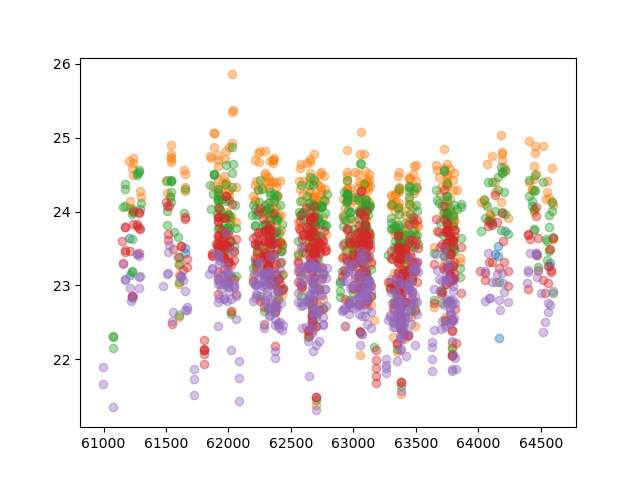

In [2]:
import matplotlib.pyplot as plt
%matplotlib widget
for f in 'ugrizY':
    plt.plot(dataSlice['observationStartMJD'][dataSlice['filter']==f],dataSlice['fiveSigmaDepth'][dataSlice['filter']==f], marker='o',linestyle='',alpha=0.4)

In [9]:
# from scipy.signal import periodogram
# periodogram([dataSlice['observationStartMJD'][dataSlice['filter']==f] for f in 'ugrizY'], fs=1.0)

In [8]:
# dataSlice['observationStartMJD'][dataSlice['filter']==f]

In [13]:
t0_max = np.percentile(dataSlice['observationStartMJD'], 1) 


61187.1570128139

In [12]:
max(dataSlice['observationStartMJD'])

64601.048799416385

In [8]:
print(min(dataSlice['observationStartMJD'])+2400000.5)
print(max(dataSlice['observationStartMJD'])+2400000.5)

2460992.515460024
2464601.5487994165


179.27192577751703


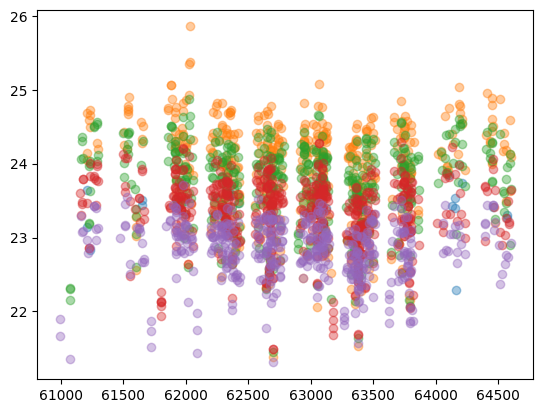

In [23]:
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from functions_roman_rubin import sim_fit,sim_event
# from functions_roman_rubin import model_rubin_roman
from functions_roman_rubin import read_data, save_sim
from fit_lc import fit_rubin_roman, model_rubin_roman
from ulens_params import event_param
import pandas as pd
seed = 0
data_TRILEGAL = pd.read_csv('../chunks_TRILEGAL_GENULENS/TRILEGAL_chunk_1.csv').iloc[seed]
data_Genulens = pd.read_csv('../chunks_TRILEGAL_GENULENS/Genulens_chunk_1.csv').iloc[seed]
system_type = 'Planets_systems'



# for seed in range(1000):
#     params = event_param(seed, data_TRILEGAL, data_Genulens, system_type, t0_range=[min(dataSlice['observationStartMJD']), max(dataSlice['observationStartMJD'])])
#     plt.errorbar(params['t0'],24,yerr=None,xerr=params['tE'])


for f in 'ugrizY':
    plt.plot(dataSlice['observationStartMJD'][dataSlice['filter']==f],dataSlice['fiveSigmaDepth'][dataSlice['filter']==f], marker='o',linestyle='',alpha=0.4)


def max_consecutive_distance(lst):
    if len(lst) < 2:
        return 0  # or raise an exception if needed
    return max(abs(lst[i+1] - lst[i]) for i in range(len(lst) - 1))

# Example usage:
values = [1, 3, 7, 2, 10]
print(max_consecutive_distance(np.sort(dataSlice['observationStartMJD'])))  # Output: 8


In [24]:
np.sort(dataSlice['observationStartMJD'])

array([60992.01546002, 60992.01857431, 61072.37116082, ...,
       64599.08747514, 64601.02458472, 64601.04879942], shape=(2051,))

(0.0, 0.6621768459992574)

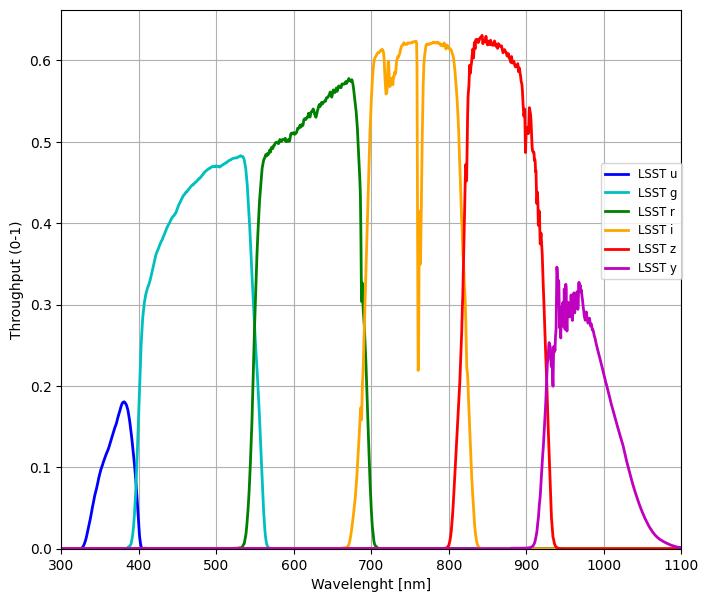

In [1]:
# from rubin_sim.phot_utils.photometric_parameters import PhotometricParameters
# from rubin_sim.phot_utils.signaltonoise import calc_mag_error_m5
import os
import matplotlib.pyplot as plt
from rubin_sim.phot_utils.bandpass import Bandpass
filterdir ='/home/anibal/rubin_sim_data/throughputs/baseline/'
lsst = {}
filterlist = ('u', 'g', 'r', 'i', 'z', 'y')
filtercolors = {'u':'b', 'g':'c', 'r':'g', 'i':'orange', 'z':'r', 'y':'m'}
for f in filterlist:
    lsst[f] = Bandpass()
    lsst[f].read_throughput(os.path.join(filterdir, 'total_'+f+'.dat'))
atmos = Bandpass()
atmos.read_throughput(os.path.join(filterdir, 'atmos_std.dat'))

plt.figure(figsize=(8,7))
for f in filterlist:
    plt.plot(lsst[f].wavelen, lsst[f].sb, color=filtercolors[f], lw=2, label='LSST %s' % (f))
# plt.plot(atmos.wavelen, atmos.sb, 'k:', label='X=1.2 std atmosphere')
plt.xlabel('Wavelenght [nm]')
plt.ylabel('Throughput (0-1)')
# plt.title('LSST Throughput Curves')
plt.xlim(300, 1100)
plt.legend(loc=(0.87, 0.5), fancybox=True, fontsize='smaller')
plt.grid(True)
plt.ylim(bottom=0)

In [2]:
from rubin_sim.phot_utils.photometric_parameters import PhotometricParameters
from rubin_sim.phot_utils.signaltonoise import calc_mag_error_m5
from rubin_sim.phot_utils.bandpass import Bandpass

LSST_BandPass = {}
lsst_filterlist = 'ugrizy'
for f in lsst_filterlist:
    LSST_BandPass[f] = Bandpass()
    LSST_BandPass[f].read_throughput('/home/anibal/rubin_sim_data/throughputs/baseline/' + f'total_{f}.dat')


def set_photometric_parameters(exptime, nexp, readnoise=None):
    # readnoise = None will use the default (8.8 e/pixel). Readnoise should be in electrons/pixel.
    photParams = PhotometricParameters(exptime=exptime, nexp=nexp, readnoise=readnoise)
    return photParams



In [5]:
photParams = set_photometric_parameters(15, 2)

In [8]:
m5 = dataSlice['fiveSigmaDepth'][np.where(dataSlice['filter'] == 'u')][0]
magerr = calc_mag_error_m5(20, LSST_BandPass['u'], m5, photParams)[0]
magerr

np.float64(0.013676601285861446)

In [3]:
filterdir ='/home/anibal/rubin_sim_data/throughputs/baseline/'
lsst = {}
filterlist = ('u', 'g', 'r', 'i', 'z', 'y')
filtercolors = {'u':'b', 'g':'c', 'r':'g', 'i':'orange', 'z':'r', 'y':'m'}
for f in filterlist:
    lsst[f] = Bandpass()
    lsst[f].read_throughput(os.path.join(filterdir, 'total_'+f+'.dat'))
atmos = Bandpass()
atmos.read_throughput(os.path.join(filterdir, 'atmos_std.dat'))

(0.0, 0.6621768459992574)

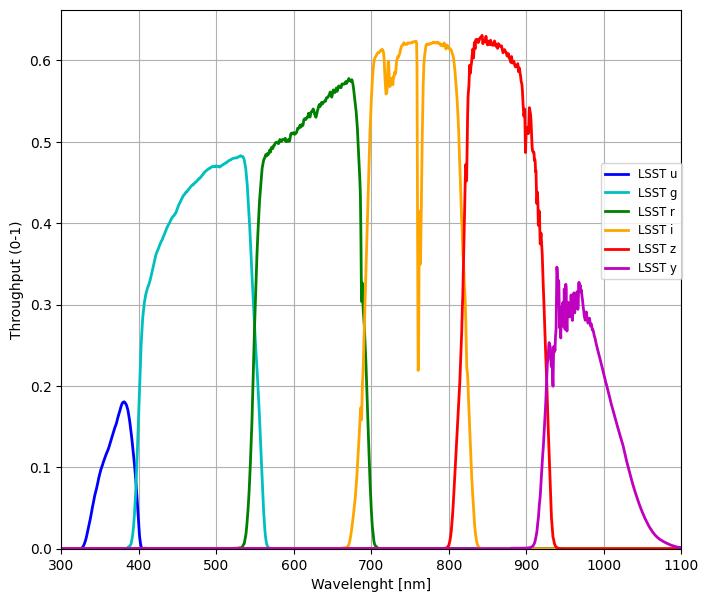

In [4]:
# Plot these curves alone.
plt.figure(figsize=(8,7))
for f in filterlist:
    plt.plot(lsst[f].wavelen, lsst[f].sb, color=filtercolors[f], lw=2, label='LSST %s' % (f))
# plt.plot(atmos.wavelen, atmos.sb, 'k:', label='X=1.2 std atmosphere')
plt.xlabel('Wavelenght [nm]')
plt.ylabel('Throughput (0-1)')
# plt.title('LSST Throughput Curves')
plt.xlim(300, 1100)
plt.legend(loc=(0.87, 0.5), fancybox=True, fontsize='smaller')
plt.grid(True)
plt.ylim(bottom=0)
# plt.savefig(os.path.join(filterdir, 'LSSTfilters.png'), format='png')

In [1]:
import os
 
from astropy import units as u
from astropy.time import Time
from matplotlib import pyplot as plt
import numpy as np
 
import synphot as syn
import stsynphot as stsyn
import stpsf

In [2]:
# Set up the Roman WFI object and retrieve the throughput of a filter
roman = stpsf.WFI()
wfi_f129 = roman._get_synphot_bandpass('F129')
print(wfi_f129(1.29 * u.micron))

0.6448


/home/anibal/anaconda3/envs/romanrubin/lib/python3.11/site-packages/stpsf/utils.py:241: UserWarning: Environment variable $STPSF_PATH is not set!

 ***********  ERROR  ******  ERROR  ******  ERROR  ******  ERROR  ***********
 *                                                                          *
 *  STPSF requires several data files to operate.                         *
 *  These files could not be located automatically at this time, or this    *
 *  version of the software requires a newer set of reference files than    *
 *  you have installed.  For more details see:                              *
 *                                                                          *
 *        https://stpsf.readthedocs.io/en/stable/installation.html        *
 *                                                                          *
 *  under "Installing the Required Data Files".                             *
 *  STPSF will not be able to function properly until the appropriate     *
 

In [3]:
band = stsyn.band('roman, wfi, f129')
print('WFI F129:')
print(f'\tBandwidth: {band.photbw():.5f}')
print(f'\tPivot wavelength: {band.pivot():.5f}')
print(f'\tFWHM: {band.fwhm():.5f}')
print(f'\tThroughput at 1.29 um: {band(1.29 * u.micron):.4f}')

IsADirectoryError: [Errno 21] Is a directory: '.'